In [1]:
import pandas as pd
import pickle


working_dir = "/home/bl4zc/bi_bl4zc/pgcoe_genepi_analytics"

###  Read in Genetic graph
with open(f'{working_dir}/data/nextstrain_tree_graph.gpickle', 'rb') as f:
    gen_G = pickle.load(f)
gen_df = pd.read_csv(f'{working_dir}/data/nextstrain_tree_dataframe.csv')

In [ ]:
### Read in epi graph
with open(f'{working_dir}/data/epi_graph.gpickle', 'rb') as f:
    epi_G = pickle.load(f)  

In [ ]:
epi_G.num_edges()


AttributeError: 'DiGraph' object has no attribute 'node'

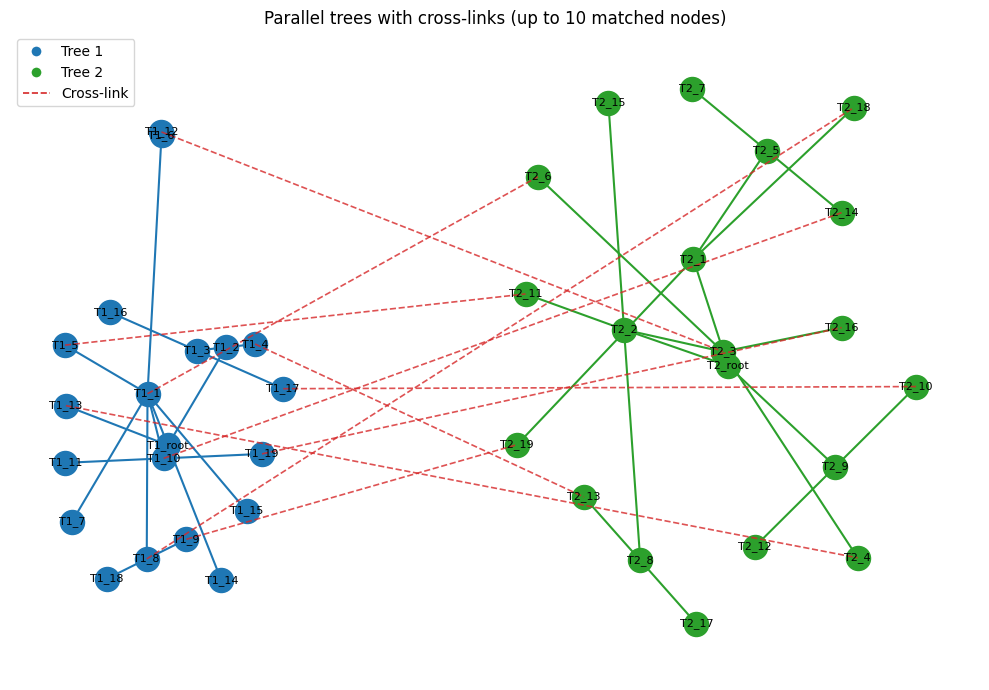

In [113]:
import random
import networkx as nx
import matplotlib.pyplot as plt

rng = random.Random(42)


def make_random_tree(prefix, num_nodes=20, max_depth=4, rng=rng):
    """Create a simple random rooted tree with bounded depth and at least 2 nodes when possible."""
    G = nx.DiGraph()
    root = f"{prefix}_root"
    G.add_node(root, depth=0)
    nodes = [root]
    depth_map = {root: 0}

    while len(nodes) < num_nodes:
        eligible_parents = [n for n in nodes if depth_map[n] < max_depth - 1]
        if not eligible_parents:
            break
        parent = rng.choice(eligible_parents)
        child = f"{prefix}_{len(nodes)}"
        child_depth = depth_map[parent] + 1
        G.add_node(child, depth=child_depth)
        G.add_edge(parent, child)
        nodes.append(child)
        depth_map[child] = child_depth

    # If we somehow only have the root, force one child
    if len(nodes) == 1 and max_depth > 1:
        child = f"{prefix}_1"
        G.add_node(child, depth=1)
        G.add_edge(root, child)
        nodes.append(child)
        depth_map[child] = 1

    return G, depth_map


def spring_positions(G, x_offset=0.0, spread=2.5, seed=42):
    pos_raw = nx.spring_layout(G, seed=seed, k=0.6 / max(len(G), 1), iterations=200)
    # center and scale
    xs = [p[0] for p in pos_raw.values()]
    ys = [p[1] for p in pos_raw.values()]
    x_mid = (max(xs) + min(xs)) / 2 if xs else 0
    y_mid = (max(ys) + min(ys)) / 2 if ys else 0
    pos = {n: ((p[0] - x_mid) * spread + x_offset, (p[1] - y_mid) * spread) for n, p in pos_raw.items()}
    return pos


# Build two random trees
G1, depth1 = make_random_tree("T1", num_nodes=20, max_depth=4, rng=rng)
G2, depth2 = make_random_tree("T2", num_nodes=20, max_depth=4, rng=rng)

nodes1 = [n for n in G1.nodes() if n != "T1_root"]
nodes2 = [n for n in G2.nodes() if n != "T2_root"]
max_pairs = min(10, len(nodes1), len(nodes2))
if max_pairs == 0:
    raise ValueError("No nodes available to match between the two trees.")
if len(nodes1) < 10 or len(nodes2) < 10:
    print(f"Warning: using {max_pairs} matched pairs because one tree has fewer than 10 non-root nodes.")

sample1 = rng.sample(nodes1, max_pairs)
sample2 = rng.sample(nodes2, max_pairs)
matched_pairs = list(zip(sample1, sample2))

# Positions from force-directed layout, shifted left/right
pos1 = spring_positions(G1, x_offset=-2.5, spread=2.0, seed=42)
pos2 = spring_positions(G2, x_offset=2.5, spread=2.0, seed=1337)
pos = {**pos1, **pos2}

fig, ax = plt.subplots(figsize=(10, 7))

nx.draw_networkx_edges(G1, pos, ax=ax, edge_color='tab:blue', arrows=False, width=1.5)
nx.draw_networkx_nodes(G1, pos, nodelist=G1.nodes(), node_color='tab:blue', ax=ax, label='Tree 1')

nx.draw_networkx_edges(G2, pos, ax=ax, edge_color='tab:green', arrows=False, width=1.5)
nx.draw_networkx_nodes(G2, pos, nodelist=G2.nodes(), node_color='tab:green', ax=ax, label='Tree 2')

# Cross-links between matched nodes
for n1, n2 in matched_pairs:
    ax.plot([pos[n1][0], pos[n2][0]], [pos[n1][1], pos[n2][1]], color='tab:red', linestyle='--', linewidth=1.2, alpha=0.8)

nx.draw_networkx_labels(G1, pos, font_size=8, ax=ax)
nx.draw_networkx_labels(G2, pos, font_size=8, ax=ax)

ax.set_title('Parallel trees with cross-links (up to 10 matched nodes)')
ax.axis('off')
ax.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', label='Tree 1', markerfacecolor='tab:blue', markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', label='Tree 2', markerfacecolor='tab:green', markersize=8),
    plt.Line2D([0], [0], color='tab:red', lw=1.2, linestyle='--', label='Cross-link')
])
plt.tight_layout()
plt.show()

In [115]:
import json
from pathlib import Path

# Build a D3-friendly node-link structure for the two trees and cross-links
# Reuse G1, G2, matched_pairs from the previous cell

def to_d3_data(G_left, G_right, matches):
    nodes = []
    links = []

    for n in G_left.nodes():
        nodes.append({"id": n, "group": "left"})
    for n in G_right.nodes():
        nodes.append({"id": n, "group": "right"})

    for u, v in G_left.edges():
        links.append({"source": u, "target": v, "type": "left"})
    for u, v in G_right.edges():
        links.append({"source": u, "target": v, "type": "right"})
    for u, v in matches:
        links.append({"source": u, "target": v, "type": "cross"})

    return {"nodes": nodes, "links": links}


d3_data = to_d3_data(G1, G2, matched_pairs)

out_dir = Path(working_dir) / "data"
out_dir.mkdir(parents=True, exist_ok=True)
json_path = out_dir / "parallel_trees_d3.json"
html_path = out_dir / "parallel_trees_d3.html"

with open(json_path, "w") as f:
    json.dump(d3_data, f, indent=2)

html_template = """
<!DOCTYPE html>
<meta charset=\"utf-8\">
<title>Parallel Trees with Cross Links</title>
<style>
  body { margin: 0; font-family: sans-serif; background: #0f1116; color: #eee; }
  svg { width: 100vw; height: 100vh; }
  .link { stroke-width: 1.5px; opacity: 0.7; }
  .link.left { stroke: #4e79a7; }
  .link.right { stroke: #59a14f; }
  .link.cross { stroke: #e15759; stroke-dasharray: 4 3; }
  .node { stroke: #fff; stroke-width: 0.5px; }
</style>
<body>
<svg></svg>
<script src=\"https://d3js.org/d3.v7.min.js\"></script>
<script>
  const width = window.innerWidth;
  const height = window.innerHeight;
  const color = d3.scaleOrdinal()
    .domain(["left", "right"])
    .range(["#4e79a7", "#59a14f"]);

  d3.json(\"parallel_trees_d3.json\").then(data => {
    const svg = d3.select("svg");

    const simulation = d3.forceSimulation(data.nodes)
      .force("link", d3.forceLink(data.links)
        .id(d => d.id)
        .distance(d => d.type === "cross" ? 120 : 40)
        .strength(d => d.type === "cross" ? 0.05 : 0.6))
      .force("charge", d3.forceManyBody().strength(-50))
      .force("center", d3.forceCenter(width / 2, height / 2))
      .force("x", d3.forceX(d => d.group === "left" ? width * 0.3 : width * 0.7).strength(0.4))
      .force("y", d3.forceY(height / 2).strength(0.1));

    const link = svg.append("g")
      .attr("stroke-linecap", "round")
      .selectAll("line")
      .data(data.links)
      .join("line")
      .attr("class", d => `link ${d.type}`);

    const node = svg.append("g")
      .selectAll("circle")
      .data(data.nodes)
      .join("circle")
      .attr("r", 5)
      .attr("fill", d => color(d.group))
      .attr("class", "node")
      .call(d3.drag()
        .on("start", dragstarted)
        .on("drag", dragged)
        .on("end", dragended));

    const label = svg.append("g")
      .selectAll("text")
      .data(data.nodes)
      .join("text")
      .text(d => d.id)
      .attr("font-size", 10)
      .attr("fill", "#ddd")
      .attr("pointer-events", "none");

    simulation.on("tick", () => {
      link
        .attr("x1", d => d.source.x)
        .attr("y1", d => d.source.y)
        .attr("x2", d => d.target.x)
        .attr("y2", d => d.target.y);

      node
        .attr("cx", d => d.x)
        .attr("cy", d => d.y);

      label
        .attr("x", d => d.x + 6)
        .attr("y", d => d.y + 3);
    });

    function dragstarted(event, d) {
      if (!event.active) simulation.alphaTarget(0.3).restart();
      d.fx = d.x;
      d.fy = d.y;
    }

    function dragged(event, d) {
      d.fx = event.x;
      d.fy = event.y;
    }

    function dragended(event, d) {
      if (!event.active) simulation.alphaTarget(0);
      d.fx = null;
      d.fy = null;
    }
  });
</script>
</body>
</html>
"""

with open(html_path, "w") as f:
    f.write(html_template)

print(f"Wrote D3 data to {json_path}")
print(f"Wrote HTML to {html_path}")
print("Open the HTML in a browser alongside the JSON in the same folder to view.")

Wrote D3 data to /home/bl4zc/bi_bl4zc/pgcoe_genepi_analytics/data/parallel_trees_d3.json
Wrote HTML to /home/bl4zc/bi_bl4zc/pgcoe_genepi_analytics/data/parallel_trees_d3.html
Open the HTML in a browser alongside the JSON in the same folder to view.
